# Smoke analysis — local smoke_test log

Parses plain-text stdout from `scripts/smoke_test.sh` (written to `scripts/smoke.txt`).

Layout-aware via `scripts/smoke_analysis/layout.py` (reads `agent.zoning.CURRENT` — FIVE one-land or TWO with NE land2 / hire5–9).

Covers hire-on-demand acceptance checks: write-on-solve, skip-not-break cascade, dawn empties (stacked land1+land2), planner zone solves (`[planner] wsp zone=…`), probe/BUY_LAND, and land2 `keep` stranding.

**Kaggle-faithful:** smokes are unseeded (env picks the seed). Compare code versions with multiple runs, not a pinned seed:

```bash
bash scripts/smoke_test.sh              # single run -> scripts/smoke.txt
SMOKE_RUNS=8 bash scripts/smoke_multi_run.sh   # distribution -> scripts/smoke_runs/
```

In [29]:
%load_ext autoreload
%autoreload 2

[zoning] CURRENT=TWO tiles=50 hands=9 KAGGRI_LANDS=2 ZONE_OPS_BUDGET=0 ZONE_OPS_MIX=1 ZONE_IDLE_FILLER=0


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "agent").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))

from smoke_analysis import (
    analyze,
    plot_earnings_by_day,
    plot_earnings_by_zone,
    plot_smoke,
    plot_worker_actions,
    summarize,
)

SMOKE_LOG = ROOT / "scripts/smoke.txt"
print(SMOKE_LOG, SMOKE_LOG.exists())

/media/wlaki/W/DS_projects/Kaggle/kaggriculture/scripts/smoke.txt True


In [31]:
report = analyze(SMOKE_LOG)
print(summarize(report))

log=smoke seed=None layout=TWO land2=5 workers reward=104810.0 smoke_passed=True buy_land_day=10
PASS total=618 HIRE total=220
replan_days=23 skip_cascade=0 infeasible=2
idle: mean_empty=1.0 land2_mean=1.1 hire5_empty_days=16 max_streak=16
stuck: workers=- healed<=5d=- permanent/slow=-
  [OK] write_day0_ge1: all day0≥1 writes present
  [OK] skip_not_break: 0 post-buy skips, cascade continued
  [OK] no_dark_land2_keep: no long land2 keep streaks
  [OK] thin_writes_logged: no thin zones
  [FAIL] hire5_idle_proxy: hire5_empty dawn days=16, hire5 empty=1 INFEASIBLE=0
  [OK] missing_from_solved: no worker missing solved ≥3 replans
  [OK] stale_start_blocks: 0 start_block age≥2
  [OK] smoke_health: parsed from log


/media/wlaki/W/DS_projects/Kaggle/kaggriculture/scripts/smoke_analysis/plot.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


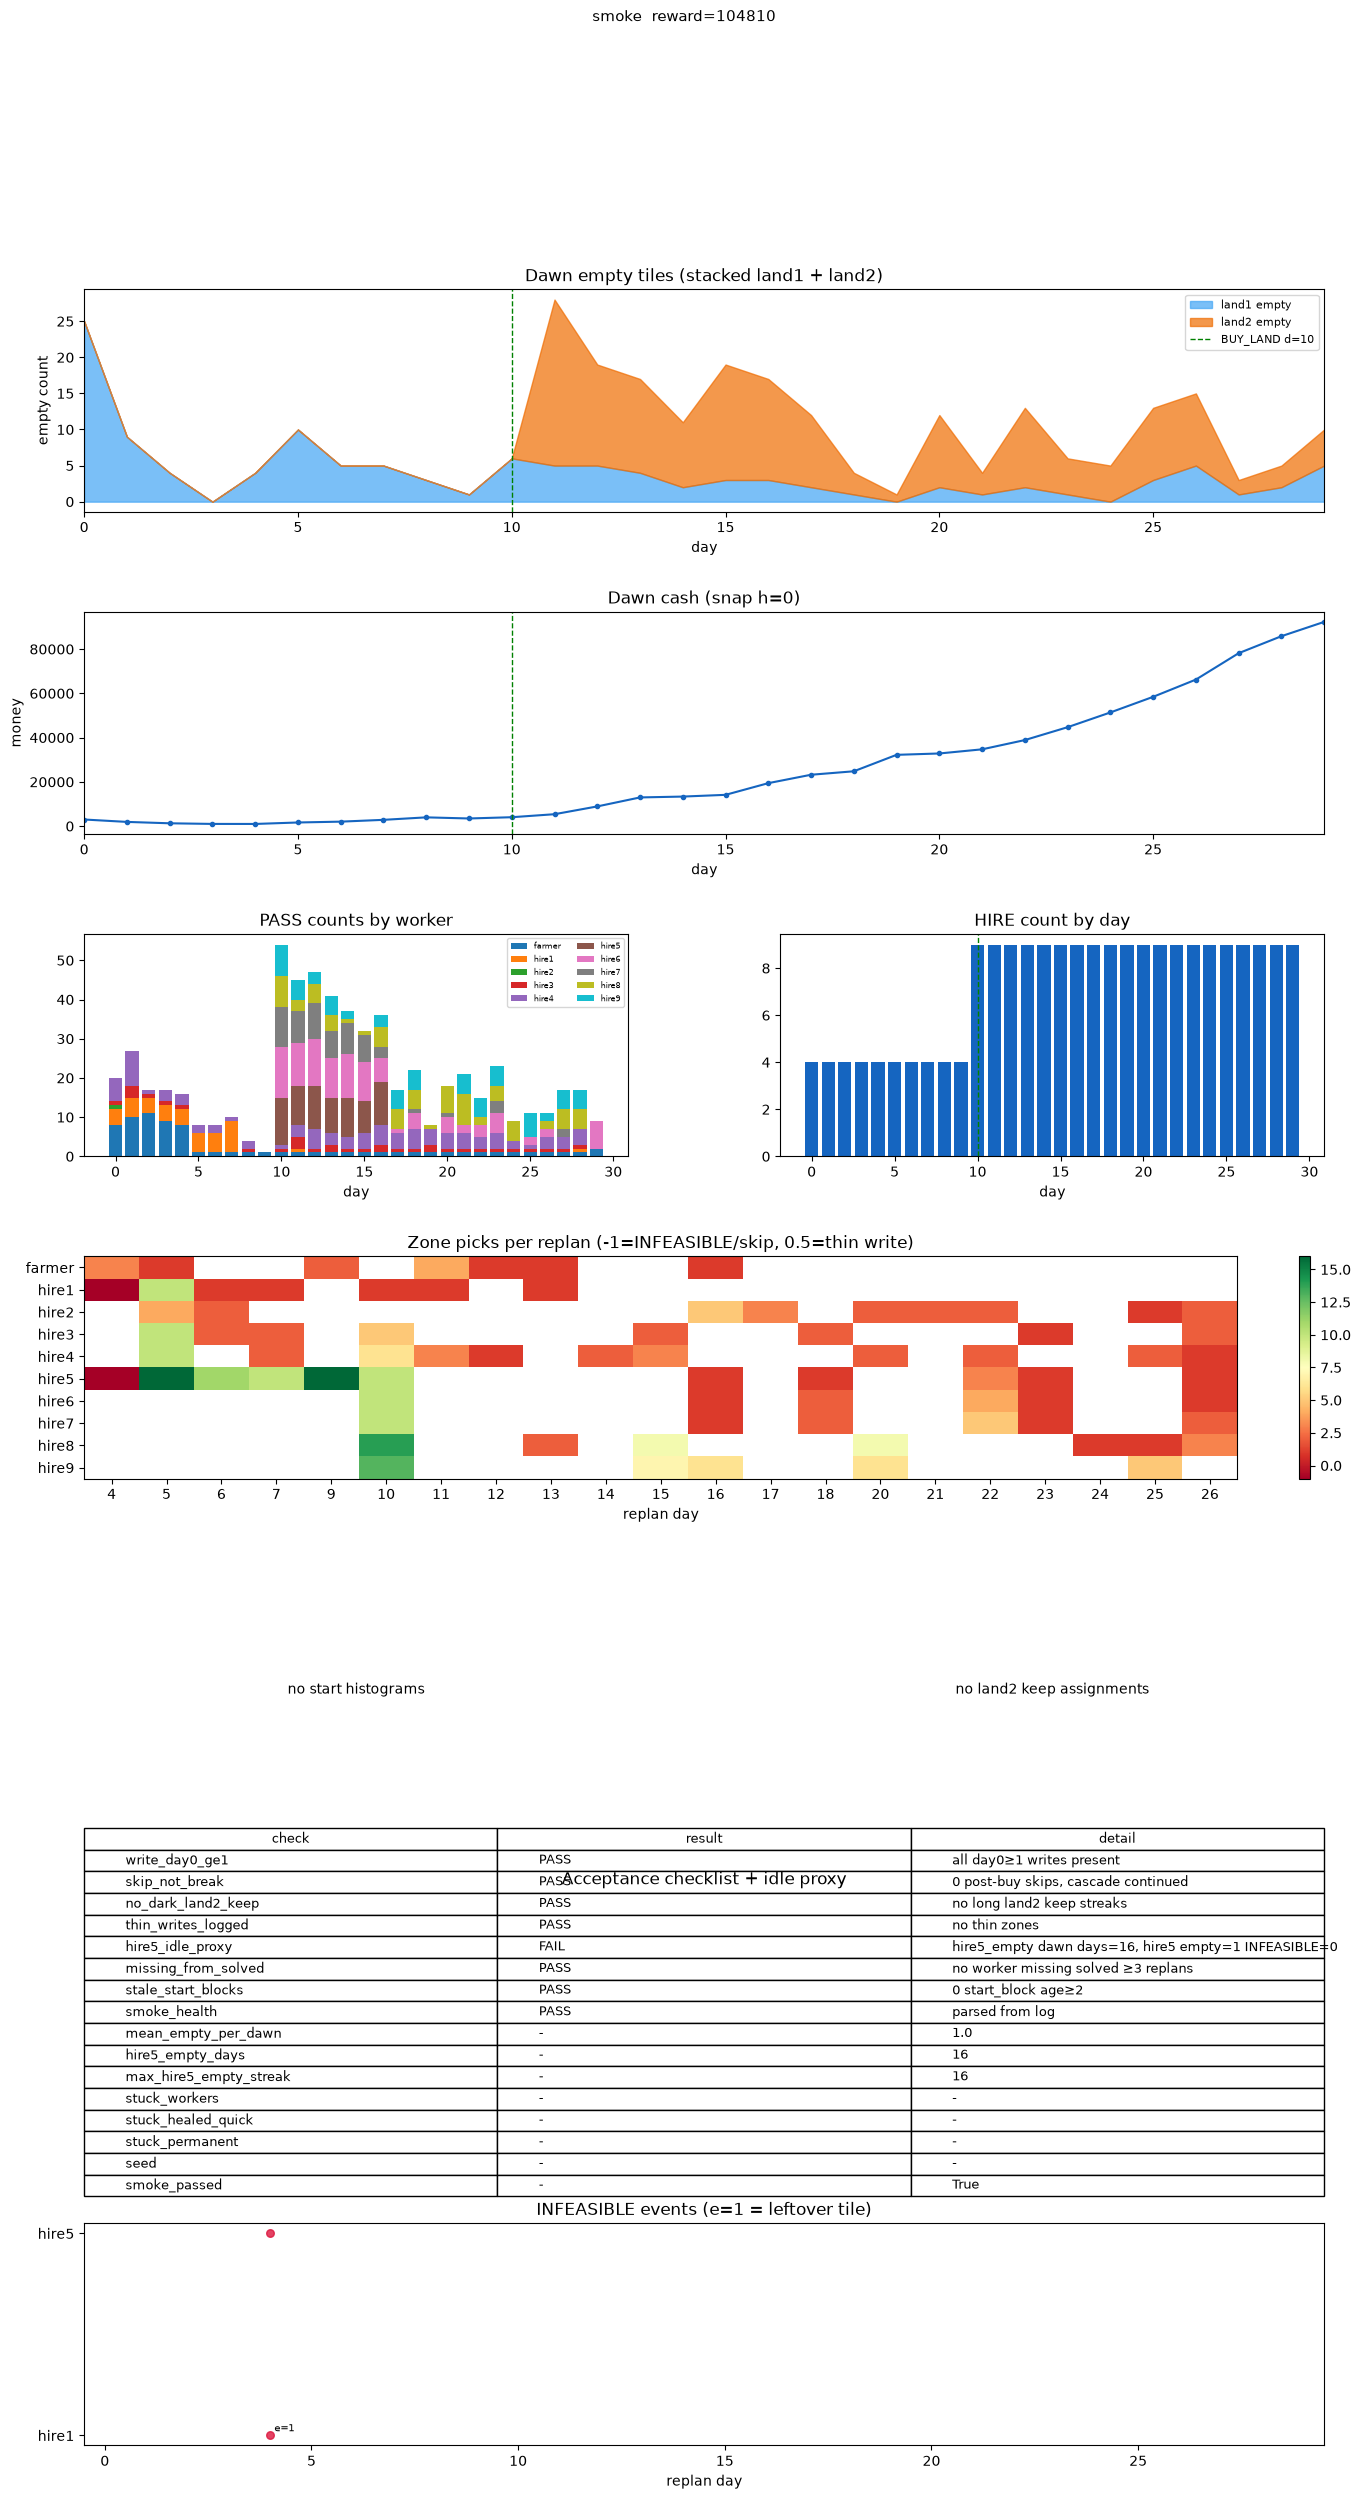

In [32]:
plot_smoke(report)

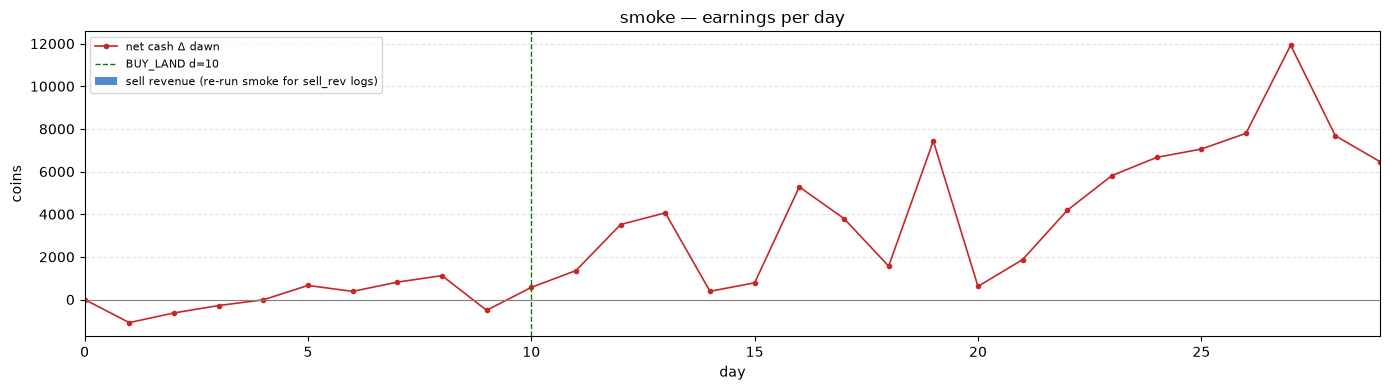

In [33]:
plot_earnings_by_day(report)

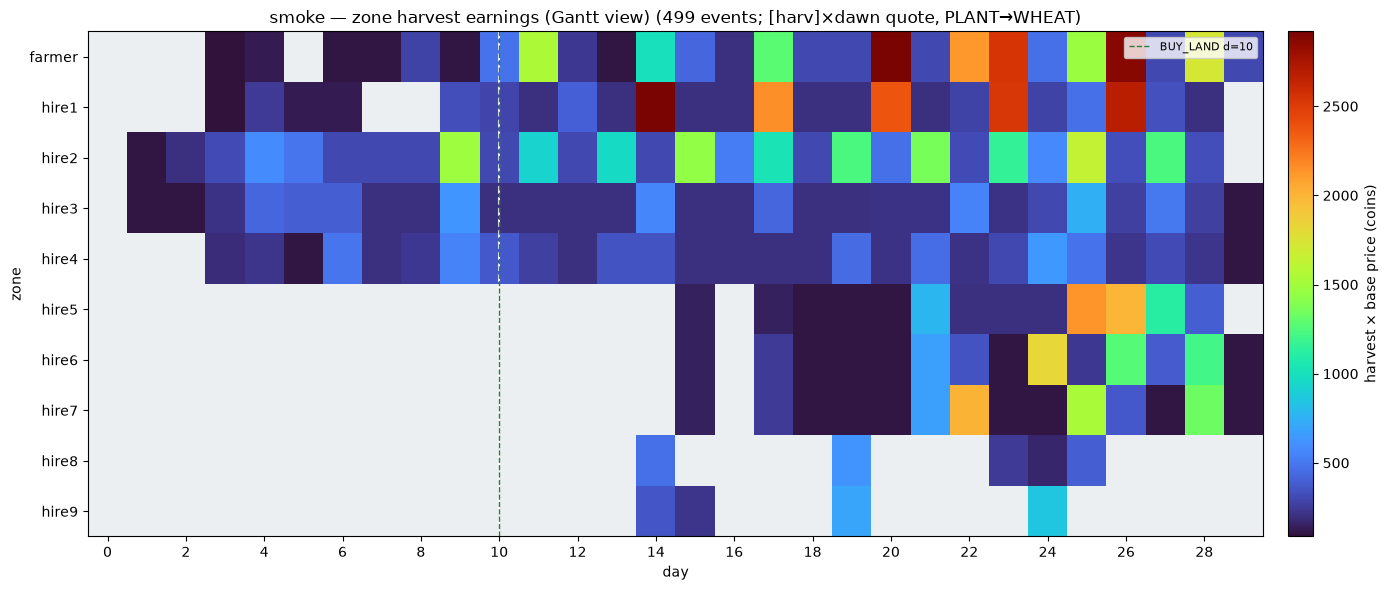

In [34]:
plot_earnings_by_zone(report)

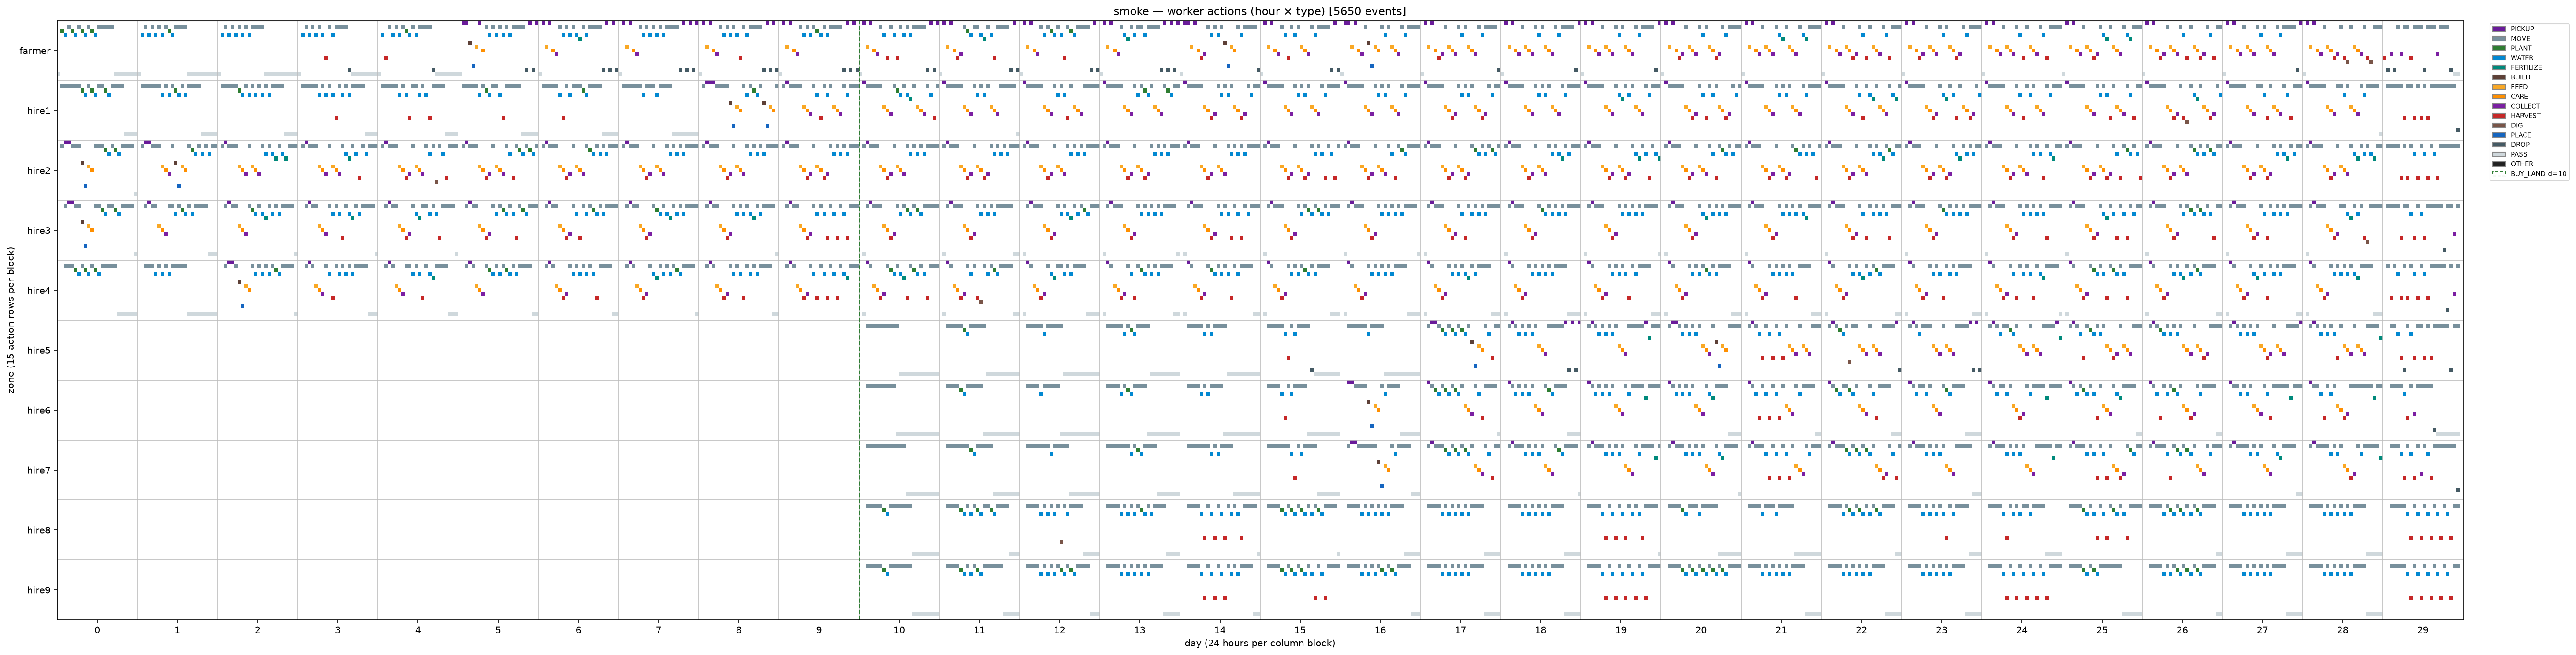

In [35]:
plot_worker_actions(report)